In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import load_img

In [ ]:
BASE_PATH = "../data/garbage/"

CATEGORIES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [ ]:
filenames = []
labels = []

for category in CATEGORIES:
    category_path = os.path.join(BASE_PATH, category)
    if not os.path.exists(category_path):
        print(f"Directory '{category_path}' does not exist.")
        continue
    files = os.listdir(category_path)

    for file in files:
        filenames.append(os.path.join(category, file))
        labels.append(category)

In [ ]:
print(f"Total images loaded: {len(filenames)}")

In [ ]:
df = pd.DataFrame({
    "filename": filenames,
    "category": labels
})

df = df.sample(frac=1).reset_index(drop=True)


In [ ]:
df.head()

,filename,category
0,paper/paper214.jpg,paper
1,plastic/plastic124.jpg,plastic
2,glass/glass257.jpg,glass
3,glass/glass240.jpg,glass
4,glass/glass201.jpg,glass


In [ ]:
unique_class = df['category'].value_counts()

In [ ]:
unique_class

paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: category, dtype: int64

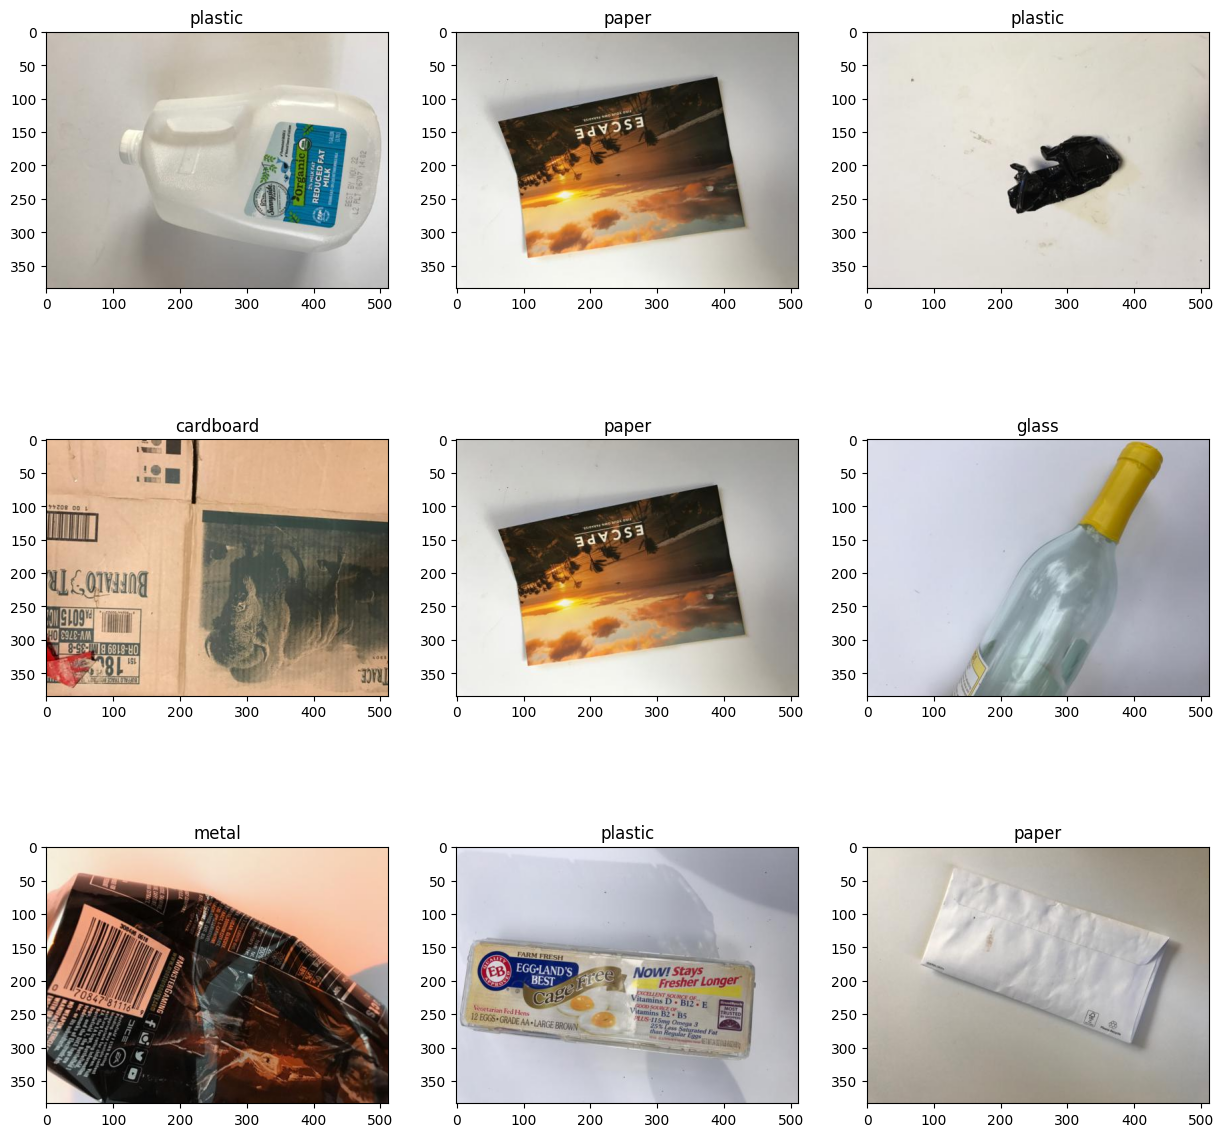

In [ ]:
import random
from keras.preprocessing import image
import keras.utils as image
plt.figure(figsize=(15,15))
for i in range(9):
    random_row = random.randint(0, len(df)-1)
    sample = df.iloc[random_row]
    random_image = image.load_img(base_path + sample['filename'])
    plt.subplot(330 + 1 + i)
    plt.title(sample['category'])
    plt.imshow(random_image)
plt.show()

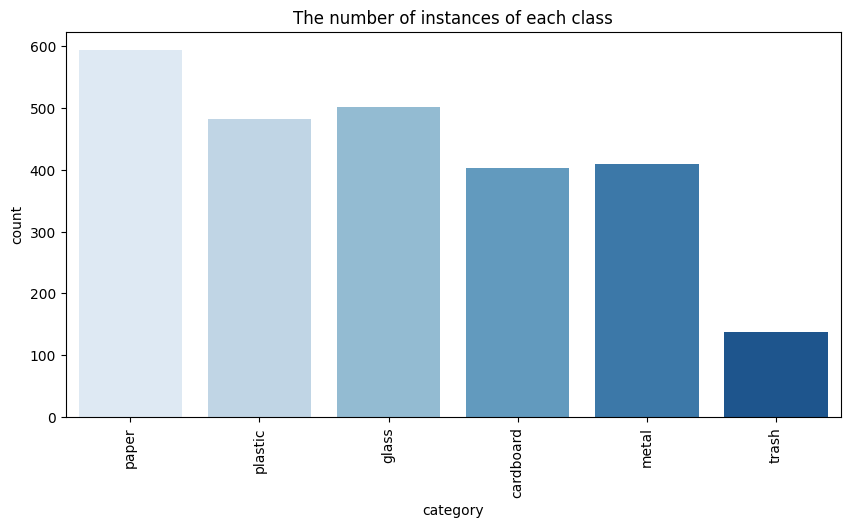

In [ ]:
#display the number of instances of each class/label
plt.figure(figsize=(10, 5))
sns.countplot(x="category", data=df, palette='Blues')
plt.xticks(rotation=90)
plt.title('The number of instances of each class')
plt.show()

## Observations

- Dataset contains 6 classes of waste materials
- Classes appear slightly imbalanced
- Images vary in lighting, angle, and background
- Some classes (e.g. plastic vs glass) are visually similar

These challenges justify the use of CNNs and data augmentation.